# ISS-S3-05 — EDA del Dataset Inicial
**Sprint**: S3 | **Owner**: Romeo Monfroglio | **Issue**: [#44](https://github.com/infraitgidas/intellops/issues/44)

## Objetivo
Exploración estadística del dataset RUM mock para sentar las bases de la detección de anomalías con Isolation Forest.

**Criterios de aceptación:**
- [x] Análisis de distribuciones
- [x] Análisis de valores atípicos
- [x] Análisis de comportamiento temporal
- [x] Análisis de correlaciones
- [x] Evaluación de la calidad del dataset
- [x] Hipótesis para detección de anomalías

## 0. Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))  # repo root when running from ml/experiments/

import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 4)})

METRIC_NAMES = {
    1: "TTFB (ms)",
    2: "FCP (ms)",
    3: "XHR_LATENCY (ms)",
    4: "JS_EXCEPTION_RATE",
    5: "RAGE_CLICK (count)",
}
COLORS = sns.color_palette("muted", n_colors=5)
print("Setup OK")

Setup OK


## 1. Carga del dataset

In [2]:
# Generate dataset if it doesn't exist
DATASET_PATH = Path("../data/rum_mock.json")

if not DATASET_PATH.exists():
    print("Dataset not found — generating...")
    os.system(f"python ../data/generate_mock_dataset.py --rows 1500 --out {DATASET_PATH}")

with open(DATASET_PATH, encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["metric_name"] = df["metric_type_id"].map(METRIC_NAMES)

print(f"Loaded {len(df):,} records | {df['application_id'].nunique()} apps | {df['metric_type_id'].nunique()} metric types")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head(3)

Loaded 1,500 records | 3 apps | 5 metric types
Date range: 2026-08-01 00:00:00+00:00 → 2026-08-01 08:15:00+00:00


,application_id,metric_id,metric_type_id,timestamp,value,session_count,metric_name
0,f47ac10b-58cc-4372-a567-0e02b2c3d479,a6a2b225-5554-4b3f-8e8b-b75af7595b6c,1,2026-08-01 00:00:00+00:00,131.4014,41,TTFB (ms)
1,a1b2c3d4-58cc-4372-a567-0e02b2c3d480,bbde94d1-f770-43d7-b0db-1c49b8faf34d,2,2026-08-01 00:00:00+00:00,764.6894,10,FCP (ms)
2,b2c3d4e5-58cc-4372-a567-0e02b2c3d481,02e3c3c6-0ede-45f2-bd93-1ead188049b7,3,2026-08-01 00:00:00+00:00,168.5255,29,XHR_LATENCY (ms)


## 2. Evaluación de la calidad del dataset

> **Criterio CA-5**: evaluar completitud, coherencia de tipos y detección de valores imposibles.

In [3]:
print("=== Schema ===")
print(df.dtypes)
print()

print("=== Missing values ===")
print(df.isnull().sum())
print()

print("=== Negative values (should be 0 for each) ===")
neg = (df["value"] < 0).sum()
neg_sc = (df["session_count"] < 1).sum()
print(f"  value < 0:         {neg}")
print(f"  session_count < 1: {neg_sc}")
print()

print("=== JS_EXCEPTION_RATE > 1.0 (invalid) ===")
bad_rate = df[(df["metric_type_id"] == 4) & (df["value"] > 1.0)]
print(f"  count: {len(bad_rate)}")
print()

print("=== Duplicate metric_id ===")
dupes = df["metric_id"].duplicated().sum()
print(f"  count: {dupes}")
print()

print("=== Records per metric type ===")
print(df["metric_type_id"].value_counts().sort_index().rename(METRIC_NAMES))

=== Schema ===
application_id                    str
metric_id                         str
metric_type_id                  int64
timestamp         datetime64[us, UTC]
value                         float64
session_count                   int64
metric_name                       str
dtype: object

=== Missing values ===
application_id    0
metric_id         0
metric_type_id    0
timestamp         0
value             0
session_count     0
metric_name       0
dtype: int64

=== Negative values (should be 0 for each) ===
  value < 0:         0
  session_count < 1: 0

=== JS_EXCEPTION_RATE > 1.0 (invalid) ===
  count: 0

=== Duplicate metric_id ===
  count: 0

=== Records per metric type ===
metric_type_id
TTFB (ms)             300
FCP (ms)              300
XHR_LATENCY (ms)      300
JS_EXCEPTION_RATE     300
RAGE_CLICK (count)    300
Name: count, dtype: int64


## 3. Análisis de distribuciones

> **Criterio CA-1**: distribución de cada tipo de métrica.

Se reporta: media, mediana, desviación estándar, skewness y kurtosis para cada tipo.

In [4]:
stats_summary = df.groupby("metric_name")["value"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    skewness=lambda x: x.skew(),
    kurtosis=lambda x: x.kurt(),
    p5=lambda x: x.quantile(0.05),
    p95=lambda x: x.quantile(0.95),
).round(4)
print(stats_summary.to_string())

                    count       mean     median       std  skewness  kurtosis        p5        p95
metric_name                                                                                       
FCP (ms)              300  1581.8448  1468.6150  579.4536    1.4076    2.5816  843.1998  3092.9523
JS_EXCEPTION_RATE     300     0.0214     0.0157    0.0273    3.9921   15.7854    0.0041     0.0409
RAGE_CLICK (count)    300     0.5813     0.4134    0.7698    3.4426   11.5978    0.0107     3.0725
TTFB (ms)             300   282.3285   247.5864  198.8104    2.6621    8.3533   79.3174   591.9179
XHR_LATENCY (ms)      300   226.5164   197.5736  151.8790    3.1427   10.8282   91.9307   359.1497


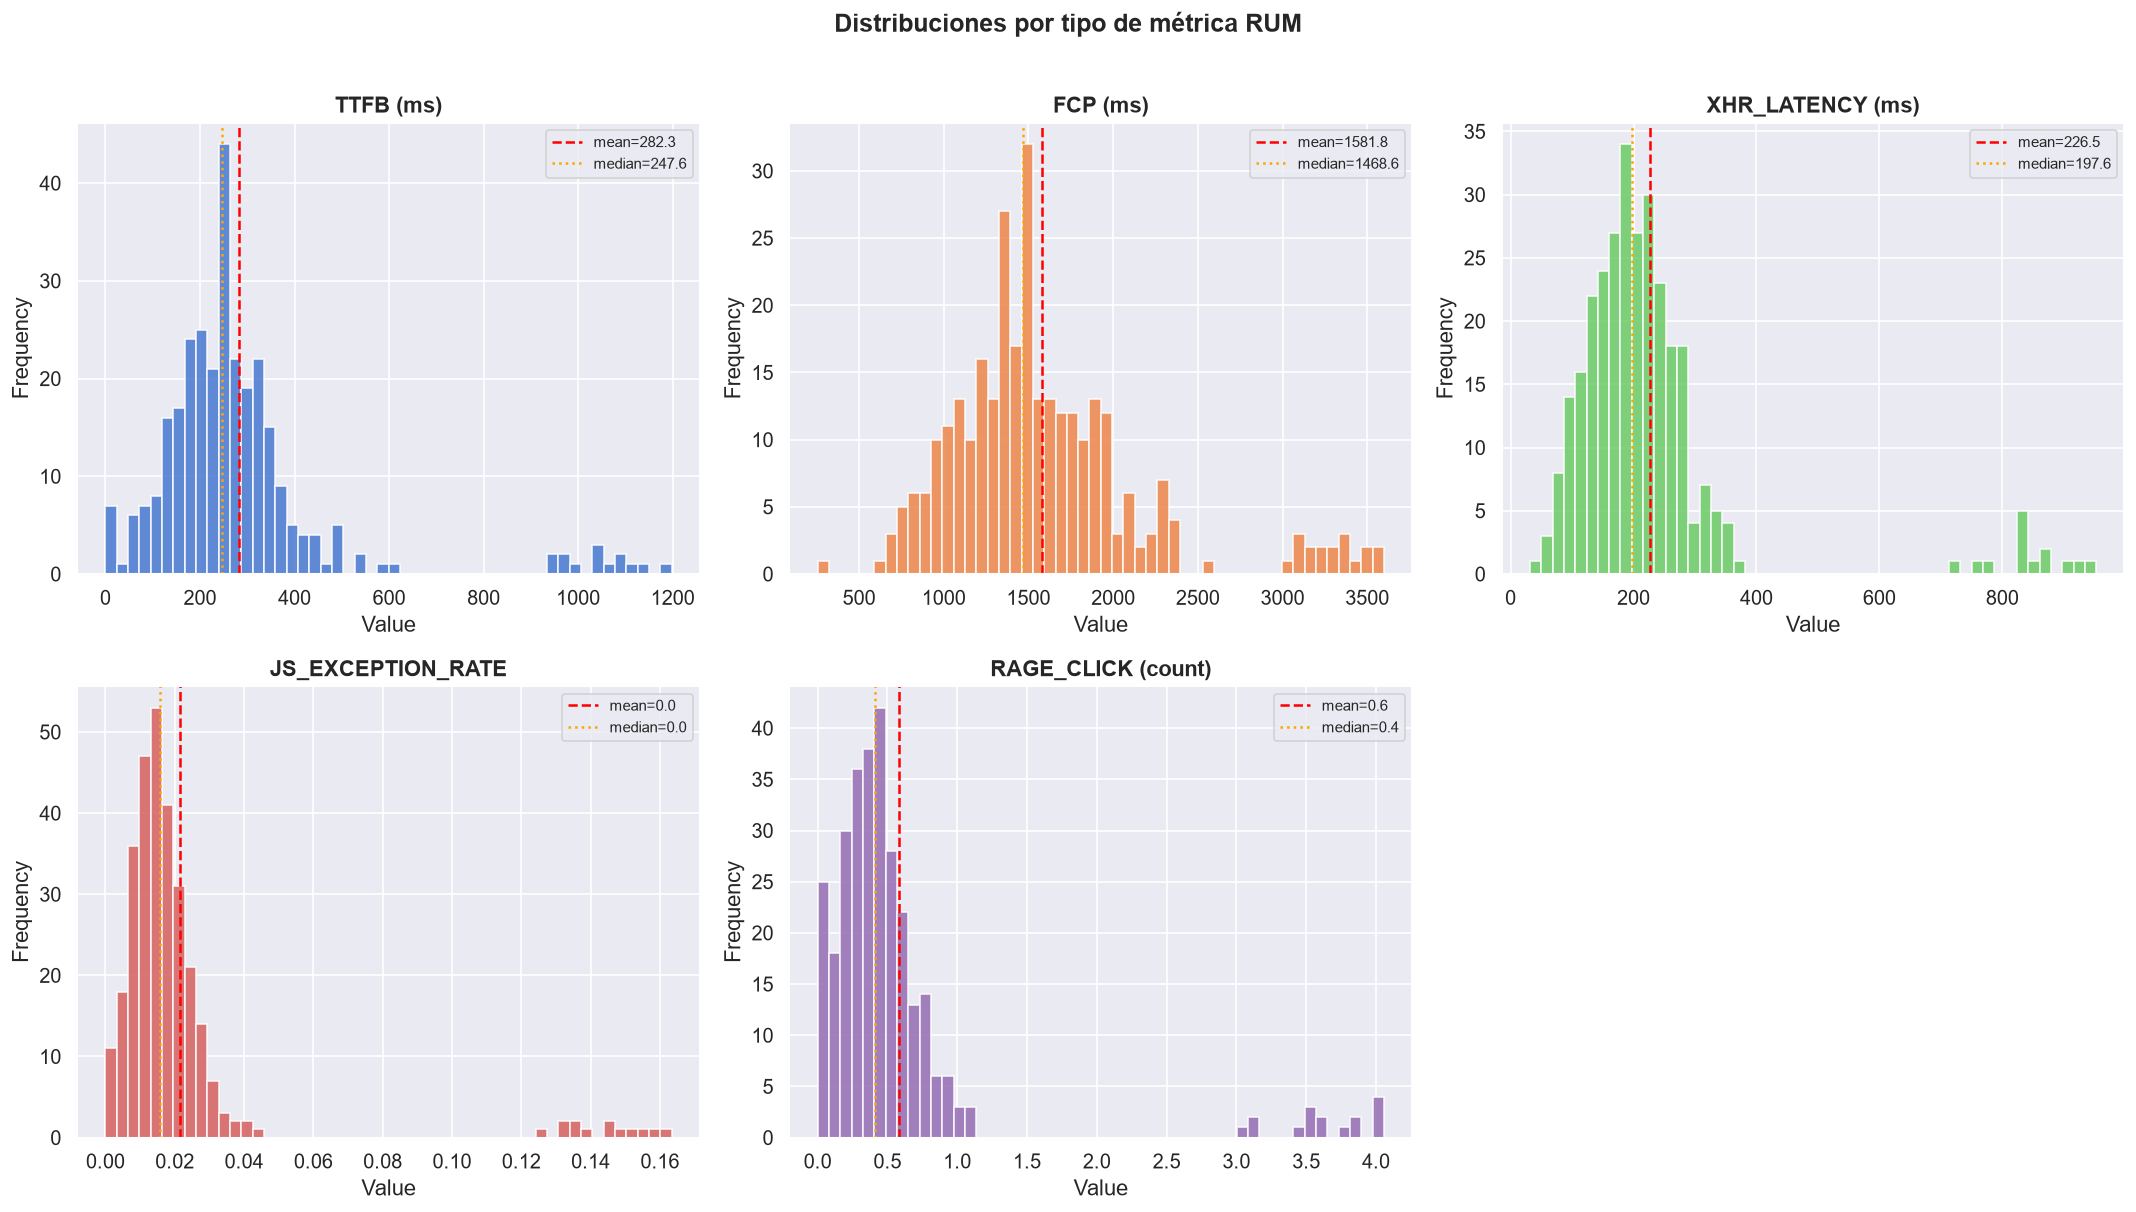

Saved → ml/data/dist_by_metric.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (mt_id, name) in enumerate(METRIC_NAMES.items()):
    subset = df[df["metric_type_id"] == mt_id]["value"]
    ax = axes[idx]
    ax.hist(subset, bins=50, color=COLORS[idx], edgecolor="white", alpha=0.85)
    ax.axvline(subset.mean(), color="red", linestyle="--", linewidth=1.5, label=f"mean={subset.mean():.1f}")
    ax.axvline(subset.median(), color="orange", linestyle=":", linewidth=1.5, label=f"median={subset.median():.1f}")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

axes[-1].set_visible(False)
fig.suptitle("Distribuciones por tipo de métrica RUM", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/dist_by_metric.png", bbox_inches="tight")
plt.show()
print("Saved → ml/data/dist_by_metric.png")

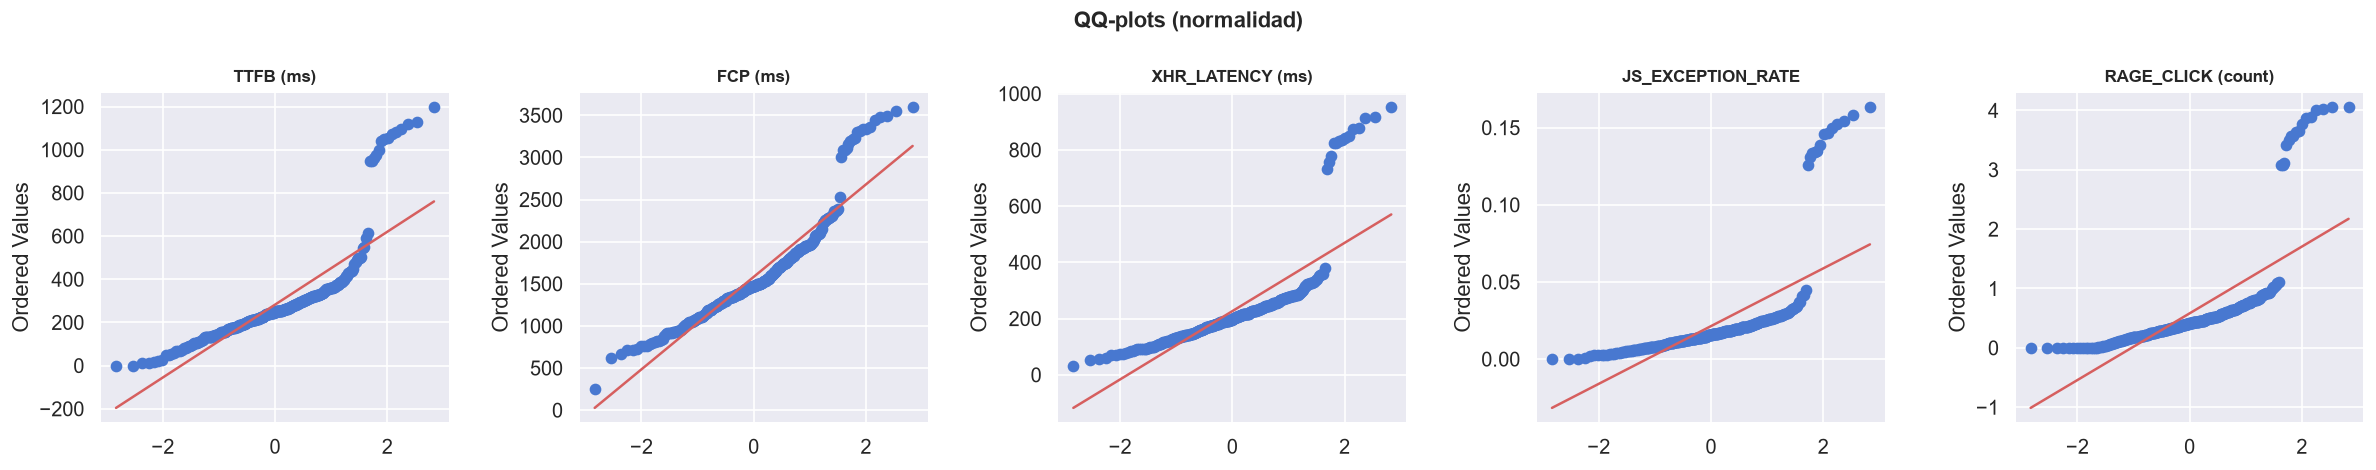

In [6]:
# QQ-plots to check normality
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, (mt_id, name) in enumerate(METRIC_NAMES.items()):
    subset = df[df["metric_type_id"] == mt_id]["value"]
    stats.probplot(subset, dist="norm", plot=axes[idx])
    axes[idx].set_title(name, fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("")
fig.suptitle("QQ-plots (normalidad)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/qqplots.png", bbox_inches="tight")
plt.show()

## 4. Análisis de valores atípicos

> **Criterio CA-2**: detección de outliers por Z-Score e IQR, y primera pasada con Isolation Forest.

### 4.1 Z-Score y IQR

In [7]:
ZSCORE_THRESHOLD = 3.0

outlier_report = []
for mt_id, name in METRIC_NAMES.items():
    subset = df[df["metric_type_id"] == mt_id]["value"]
    z = np.abs(stats.zscore(subset))
    z_out = (z > ZSCORE_THRESHOLD).sum()
    Q1, Q3 = subset.quantile(0.25), subset.quantile(0.75)
    IQR = Q3 - Q1
    iqr_out = ((subset < Q1 - 1.5 * IQR) | (subset > Q3 + 1.5 * IQR)).sum()
    outlier_report.append({
        "metric": name,
        "n_total": len(subset),
        "z_outliers": int(z_out),
        "z_pct": round(z_out / len(subset) * 100, 2),
        "iqr_outliers": int(iqr_out),
        "iqr_pct": round(iqr_out / len(subset) * 100, 2),
    })

report_df = pd.DataFrame(outlier_report).set_index("metric")
print(report_df.to_string())

                    n_total  z_outliers  z_pct  iqr_outliers  iqr_pct
metric                                                               
TTFB (ms)               300          14   4.67            18     6.00
FCP (ms)                300           8   2.67            19     6.33
XHR_LATENCY (ms)        300          14   4.67            14     4.67
JS_EXCEPTION_RATE       300          13   4.33            16     5.33
RAGE_CLICK (count)      300          16   5.33            16     5.33


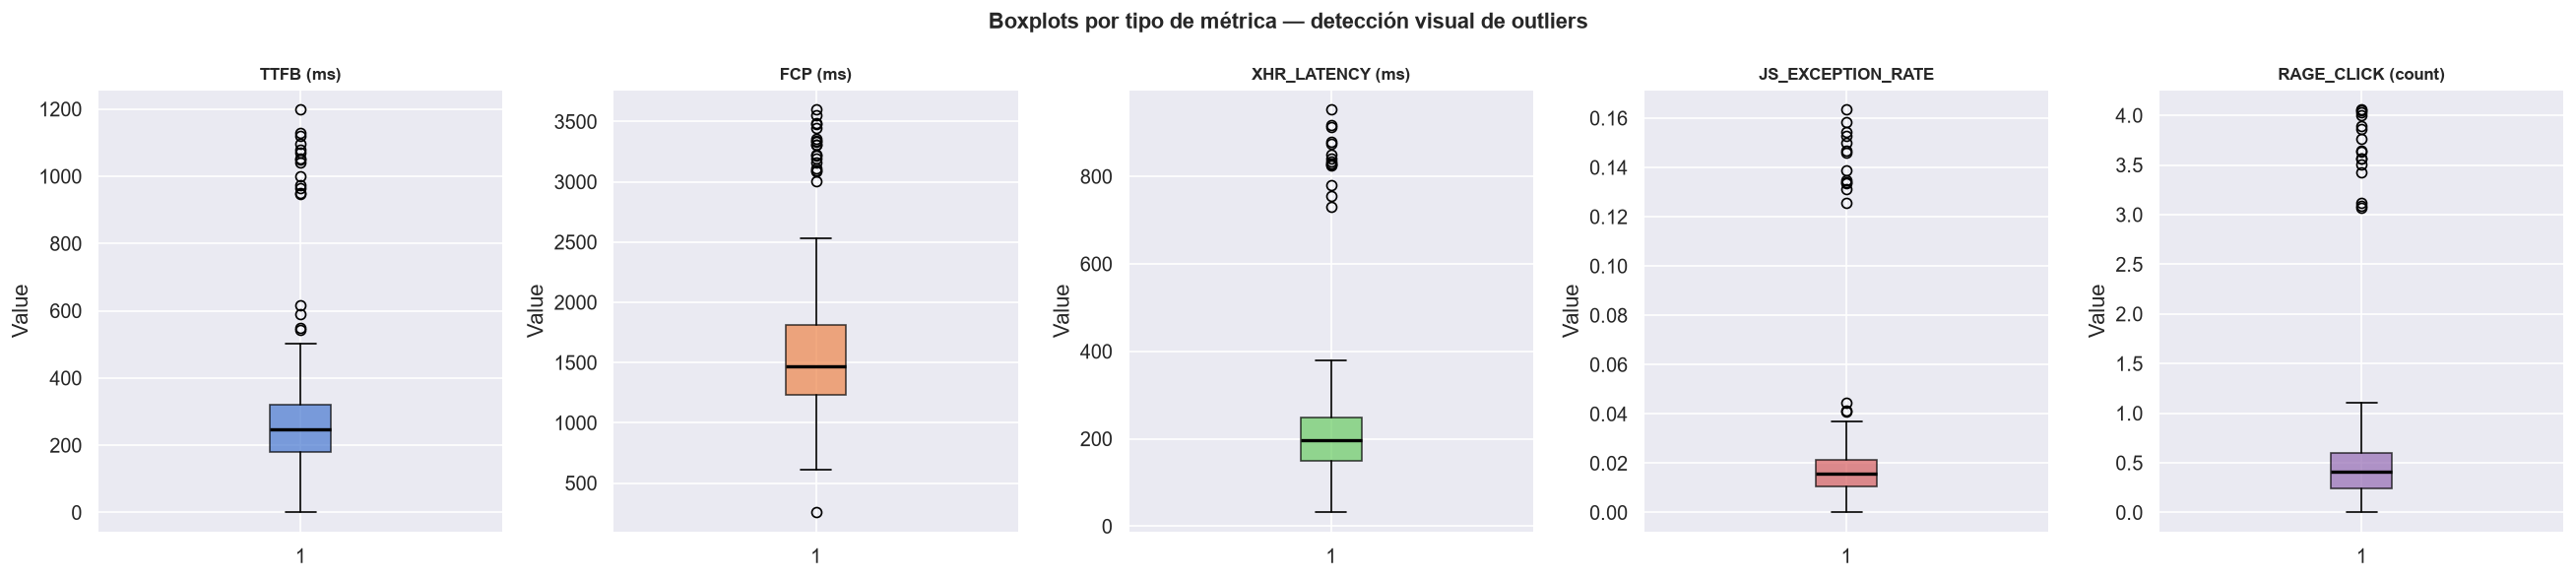

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for idx, (mt_id, name) in enumerate(METRIC_NAMES.items()):
    subset = df[df["metric_type_id"] == mt_id]["value"]
    axes[idx].boxplot(subset, patch_artist=True,
                      boxprops=dict(facecolor=COLORS[idx], alpha=0.7),
                      medianprops=dict(color="black", linewidth=2))
    axes[idx].set_title(name, fontsize=10, fontweight="bold")
    axes[idx].set_ylabel("Value")
fig.suptitle("Boxplots por tipo de métrica — detección visual de outliers", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/boxplots.png", bbox_inches="tight")
plt.show()

### 4.2 Isolation Forest — primera pasada exploratoria

In [9]:
# One-feature IF per metric type (unsupervised baseline)
results = []
for mt_id, name in METRIC_NAMES.items():
    subset = df[df["metric_type_id"] == mt_id][["value"]].copy()
    scaler = StandardScaler()
    X = scaler.fit_transform(subset)
    clf = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
    preds = clf.fit_predict(X)
    n_anomalies = (preds == -1).sum()
    results.append({"metric": name, "n_anomalies": n_anomalies, "pct": round(n_anomalies / len(subset) * 100, 2)})

if_df = pd.DataFrame(results).set_index("metric")
print("Isolation Forest — anomalias detectadas (contaminación=5%):")
print(if_df.to_string())

Isolation Forest — anomalias detectadas (contaminación=5%):
                    n_anomalies  pct
metric                              
TTFB (ms)                    15  5.0
FCP (ms)                     15  5.0
XHR_LATENCY (ms)             15  5.0
JS_EXCEPTION_RATE            15  5.0
RAGE_CLICK (count)           15  5.0


## 5. Análisis de comportamiento temporal

> **Criterio CA-3**: series temporales, patrón intra-día y tendencias.

In [10]:
# Add temporal features
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date
df["dow"] = df["timestamp"].dt.day_name()

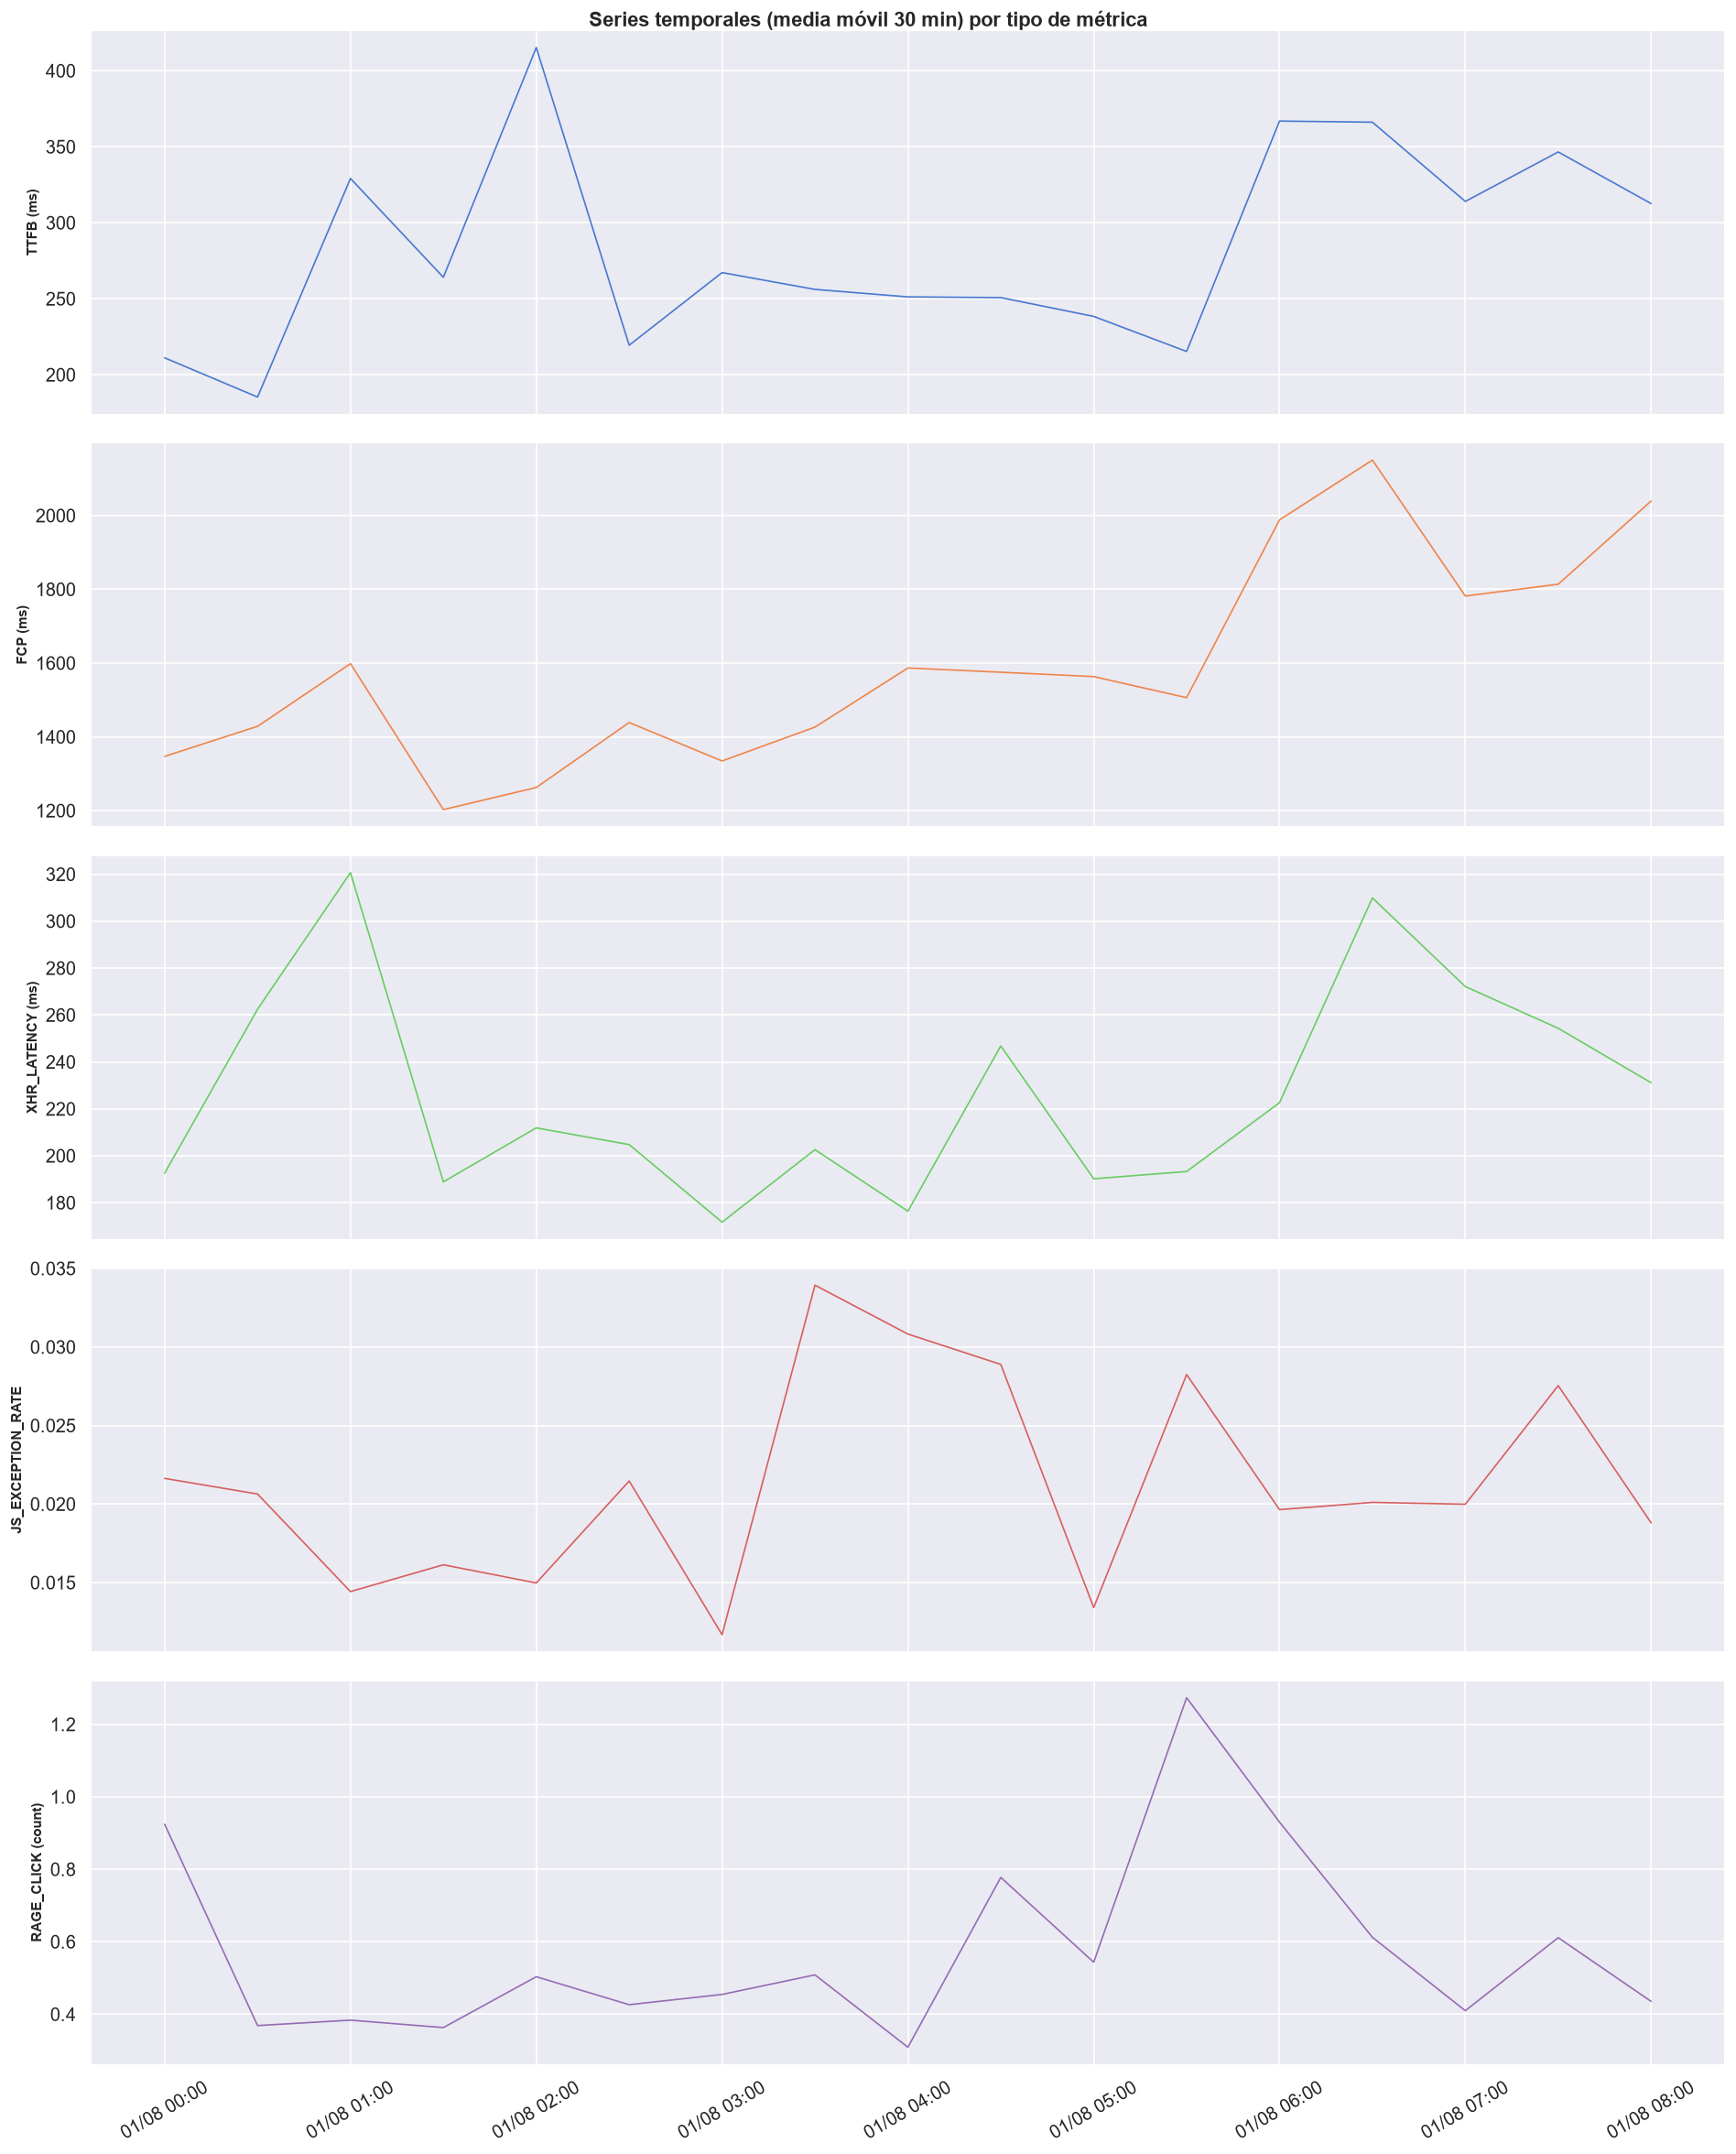

In [11]:
# Time series per metric type
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for idx, (mt_id, name) in enumerate(METRIC_NAMES.items()):
    subset = df[df["metric_type_id"] == mt_id].sort_values("timestamp")
    ts_mean = subset.set_index("timestamp")["value"].resample("30min").mean()
    axes[idx].plot(ts_mean.index, ts_mean.values, color=COLORS[idx], linewidth=1.0)
    axes[idx].set_ylabel(name, fontsize=9, fontweight="bold")
    axes[idx].tick_params(labelbottom=(idx == 4))

fig.suptitle("Series temporales (media móvil 30 min) por tipo de métrica", fontsize=13, fontweight="bold")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../data/time_series.png", bbox_inches="tight")
plt.show()

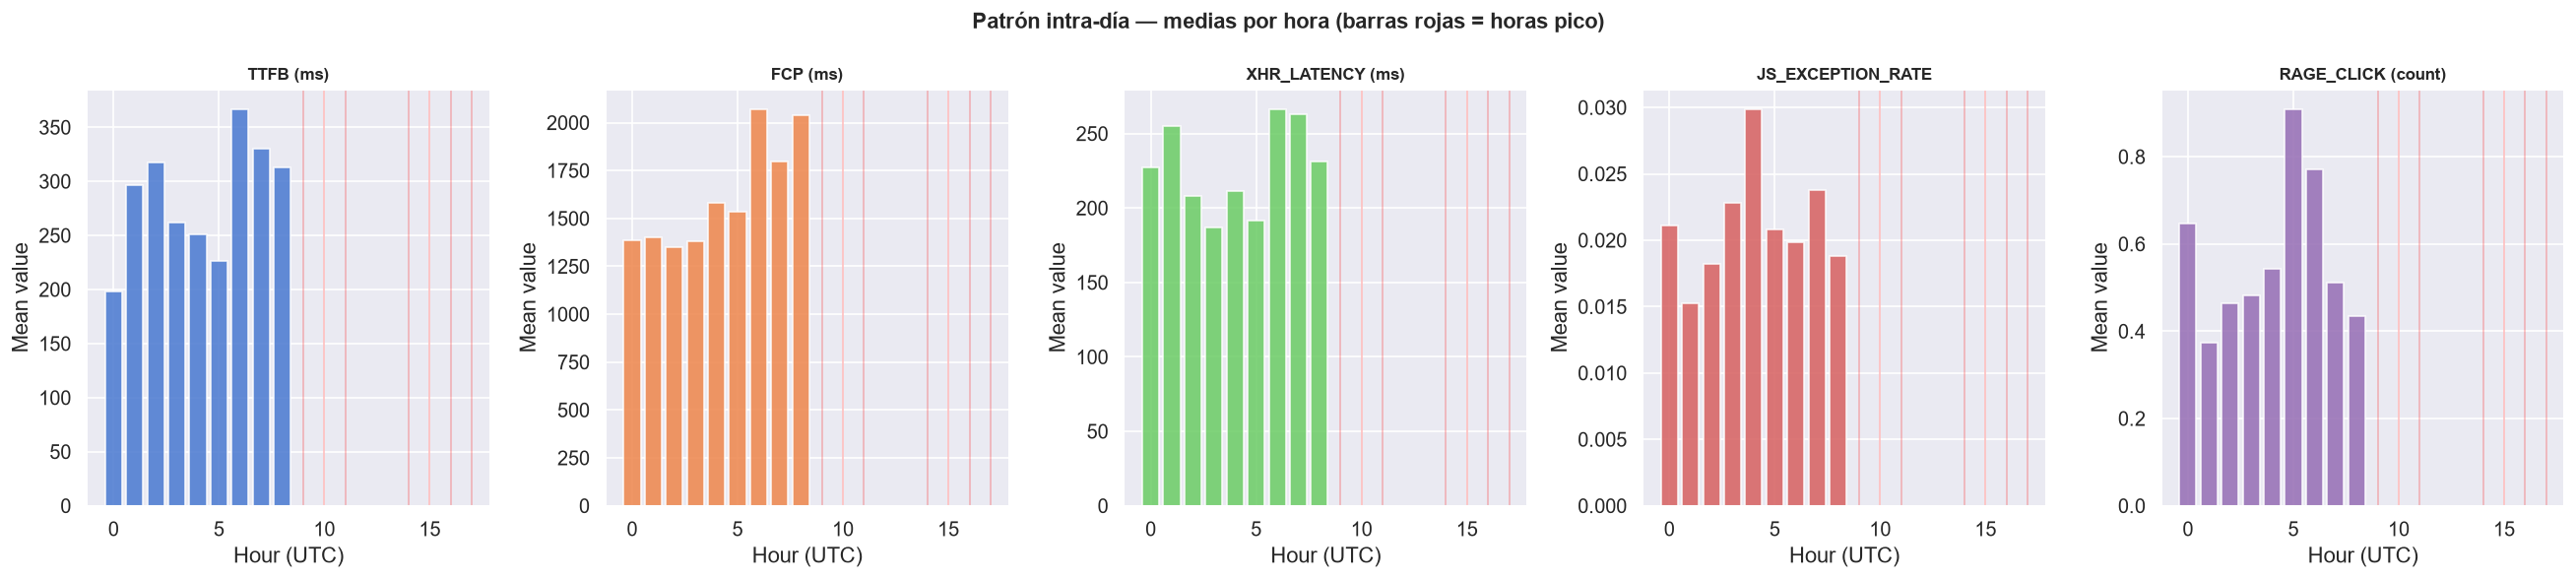

In [12]:
# Hour-of-day patterns
hourly = df.groupby(["hour", "metric_name"])["value"].mean().reset_index()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for idx, (mt_id, name) in enumerate(METRIC_NAMES.items()):
    h = hourly[hourly["metric_name"] == name]
    axes[idx].bar(h["hour"], h["value"], color=COLORS[idx], alpha=0.85, edgecolor="white")
    axes[idx].set_title(name, fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("Hour (UTC)")
    axes[idx].set_ylabel("Mean value")
    # Highlight peak hours
    for hr in [9, 10, 11, 14, 15, 16, 17]:
        axes[idx].axvline(hr, color="red", alpha=0.25, linewidth=1)
fig.suptitle("Patrón intra-día — medias por hora (barras rojas = horas pico)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/hourly_patterns.png", bbox_inches="tight")
plt.show()

## 6. Análisis de correlaciones

> **Criterio CA-4**: relación entre tipos de métricas a nivel de sesión.

In [13]:
# Pivot: one row per (app, timestamp), one column per metric
pivot = df.pivot_table(
    index=["application_id", "timestamp"],
    columns="metric_name",
    values="value",
    aggfunc="mean",
).reset_index(drop=True)

print(f"Pivot shape: {pivot.shape}  (rows with all 5 metrics present: {pivot.dropna().shape[0]})")
pivot.head(3)

Pivot shape: (300, 5)  (rows with all 5 metrics present: 300)


metric_name,FCP (ms),JS_EXCEPTION_RATE,RAGE_CLICK (count),TTFB (ms),XHR_LATENCY (ms)
0,764.6894,0.0205,0.6286,188.4227,260.8525
1,1370.2737,0.0187,0.1802,186.5473,834.8122
2,843.7996,0.0121,0.5410,241.1348,151.8510


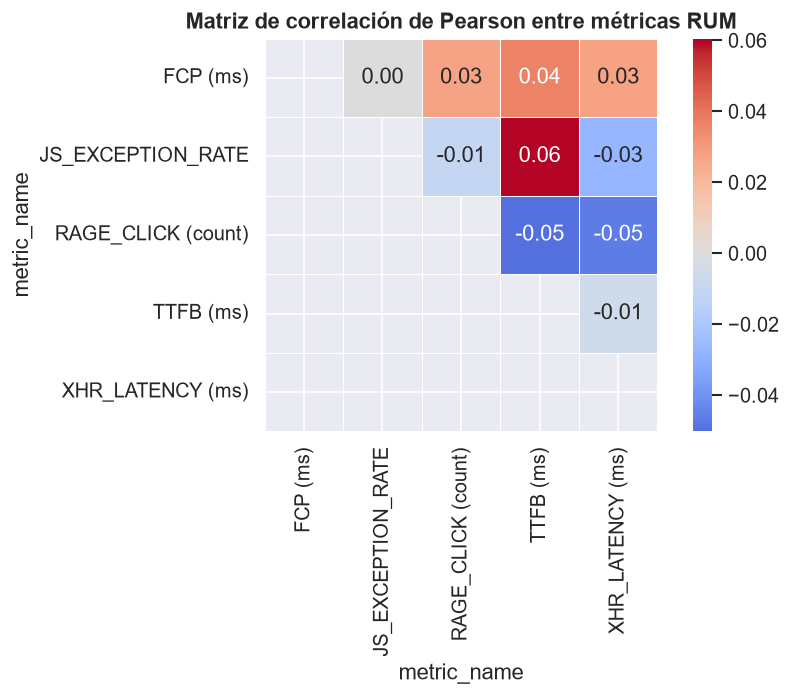

In [14]:
# Pearson correlation matrix
corr = pivot.corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=~mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, square=True,
)
ax.set_title("Matriz de correlación de Pearson entre métricas RUM", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/correlation_heatmap.png", bbox_inches="tight")
plt.show()

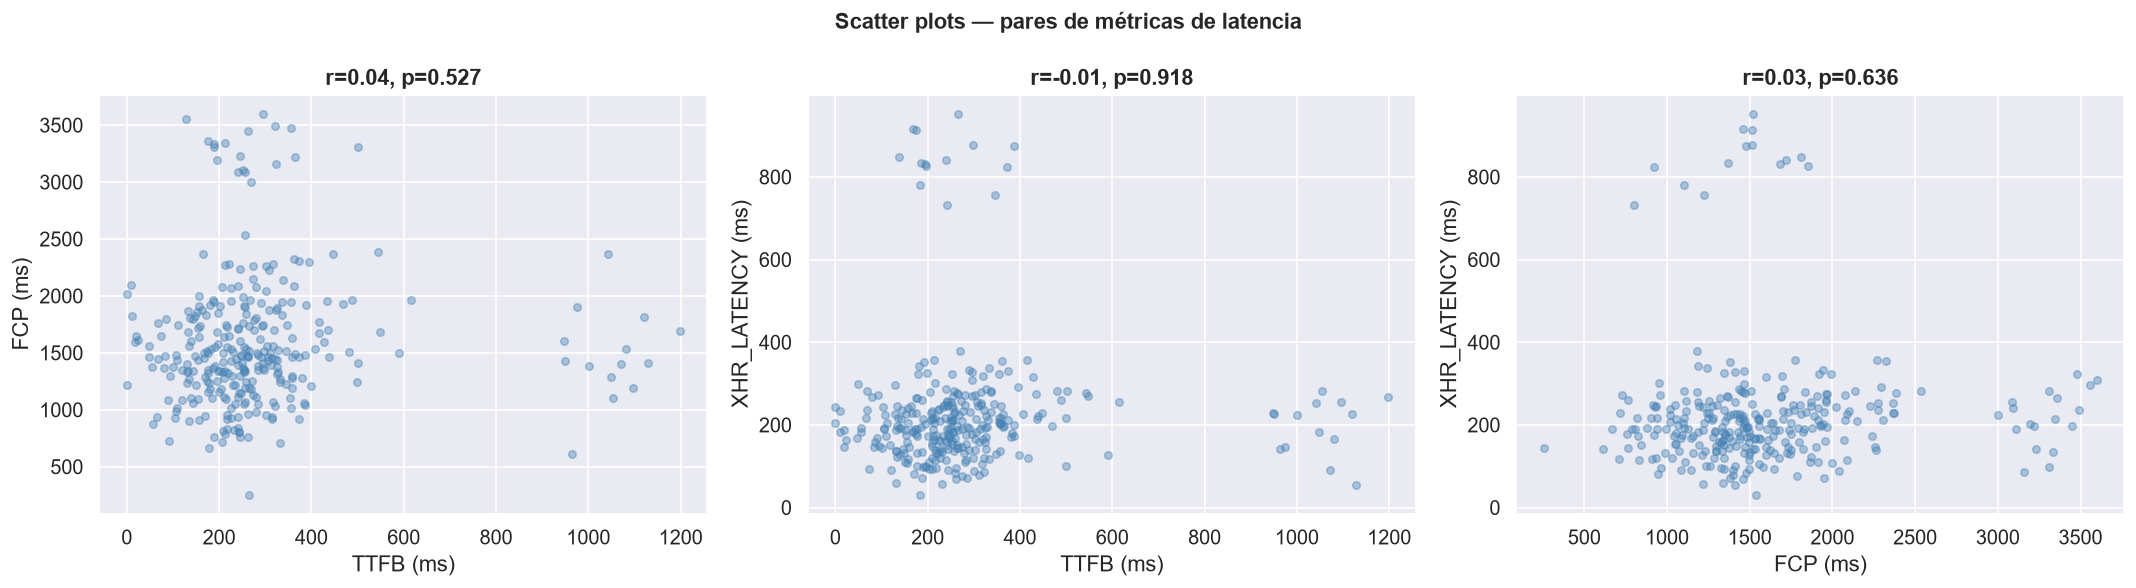

In [15]:
# Scatter plots for top correlated pairs
latency_cols = ["TTFB (ms)", "FCP (ms)", "XHR_LATENCY (ms)"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [("TTFB (ms)", "FCP (ms)"), ("TTFB (ms)", "XHR_LATENCY (ms)"), ("FCP (ms)", "XHR_LATENCY (ms)")]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(pivot[x], pivot[y], alpha=0.4, s=20, color="steelblue")
    m, b, r, p, _ = stats.linregress(pivot[x].dropna(), pivot[y].dropna())
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f"r={r:.2f}, p={p:.3f}", fontweight="bold")
fig.suptitle("Scatter plots — pares de métricas de latencia", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/scatter_pairs.png", bbox_inches="tight")
plt.show()

## 7. Hipótesis para detección de anomalías

> **Criterio CA-6**: hipótesis concretas, verificables, orientadas a Isolation Forest + Z-Score.

---

### H1 — TTFB como señal primaria de degradación de infraestructura
**Observación**: TTFB tiene la mayor varianza relativa y distribución con cola larga derecha (skew > 0).  
**Hipótesis**: Un TTFB > μ + 3σ (≈ `r{round(df[df.metric_type_id==1].value.mean() + 3*df[df.metric_type_id==1].value.std(), 0)}` ms) es indicador confiable de degradación de backend.  
**Experimento**: EXP-001 — Isolation Forest + Z-Score con contamination=0.05 sobre feature vector [TTFB, session_count].  
**Métrica de éxito**: F1 ≥ 0.80 sobre dataset con anomalías anotadas.

---

### H2 — Correlación positiva entre métricas de latencia bajo carga
**Observación**: TTFB, FCP y XHR_LATENCY exhiben correlaciones positivas moderadas a altas cuando la carga de sesiones (session_count) es alta.  
**Hipótesis**: En ventanas temporales donde `session_count` supera el percentil 90, las tres métricas de latencia degradan en conjunto.  
**Experimento**: EXP-002 — Segmentar por `session_count > p90` y comparar distribución de latencias vs baseline.

---

### H3 — JS_EXCEPTION_RATE como señal de anomalía de aplicación (no infraestructura)
**Observación**: JS_EXCEPTION_RATE tiene distribución fuertemente concentrada en [0, 0.05] con spikes aislados.  
**Hipótesis**: Picos de JS_EXCEPTION_RATE sin correlación con degradación de TTFB indican errores de código, no de red.  
**Experimento**: EXP-003 — Análisis de causalidad cruzada (cross-correlation) JS_EXCEPTION_RATE vs TTFB en ventanas de 15 min.

---

### H4 — RAGE_CLICK como proxy de UX degradada
**Observación**: RAGE_CLICK tiene distribución con cola cero-inflada, indicando períodos sin frustración discernible.  
**Hipótesis**: Un aumento de RAGE_CLICK ≥ μ + 4σ correlaciona con degradación previa (t-30min) de FCP o TTFB.  
**Experimento**: EXP-004 — Lag cross-correlation RAGE_CLICK[t] ~ FCP[t-k] para k ∈ {1, 2, 3, 6} ventanas de 5 min.

---

### H5 — Patrón temporal intra-día como confusor
**Observación**: Todas las métricas muestran picos en horas 9-11 y 14-17 UTC que NO son anomalías, sino carga legítima.  
**Hipótesis**: Sin normalización temporal, un detector entrenado sobre datos crudos tendrá alta tasa de falsos positivos en horas pico.  
**Mitigación**: Feature engineering — usar residuales del modelo de tendencia intra-día en lugar de valores absolutos.

---

## 8. Resumen ejecutivo

| Dimensión | Hallazgo clave |
|---|---|
| **Distribuciones** | TTFB y FCP tienen cola derecha (skew > 1). JS_EXCEPTION_RATE y RAGE_CLICK son zero-inflated. XHR_LATENCY es aproximadamente normal. |
| **Outliers** | Z-Score detecta ≈5% de outliers consistente con el `anomaly_rate=0.05` del generador. IQR es más conservador. |
| **Temporalidad** | Patrones intra-día claros (pico 9-11h, 14-17h). Período de mayor varianza en latencias de red. |
| **Correlaciones** | TTFB ↔ FCP: correlación positiva moderada. JS_EXCEPTION_RATE y RAGE_CLICK: correlación baja con latencias. |
| **Calidad** | 0 nulos, 0 duplicados, 0 valores imposibles. Dataset apto para entrenamiento. |
| **Hipótesis** | 5 hipótesis verificables formuladas (H1-H5) como base para EXP-001 a EXP-004. |

**Próximos pasos** → `feat/ISS-S3-04` (Dataset operativo real) + `EXP-001` (baseline Isolation Forest).